# Task 002 - Data Preparation

## CRISP-DM Phase 3

---

# مقدمه

در تسک قبلی شما مرحله **Data Understanding** را روی دیتاست بیماری قلبی انجام دادید.

در پایان آن مرحله باید به درک مناسبی از موارد زیر رسیده باشید:

* ساختار داده
* کیفیت داده
* ویژگی‌های مهم
* ارتباط ویژگی‌ها با متغیر هدف
* مشکلات موجود در داده
* مناسب بودن داده برای مدل‌سازی

اکنون وارد مرحله سوم فرآیند CRISP-DM یعنی **Data Preparation** می‌شویم.

---

# یادآوری چالش کسب‌وکار

شما به عنوان تحلیلگر داده در یک مرکز درمانی قلب و عروق فعالیت می‌کنید.

هدف کسب‌وکار:

تشخیص احتمال ابتلا به بیماری قلبی بر اساس ویژگی‌های بیماران.

متغیر هدف:

```python
target
```

* 0 → Healthy
* 1 → Heart Disease

---

# نوع مسئله داده‌کاوی

با توجه به تحلیل مرحله قبل:

متغیر هدف مشخص است و دو کلاس دارد.

بنابراین مسئله اصلی:

## Supervised Learning

و به طور دقیق‌تر:

## Binary Classification

---

# الگوریتم‌های احتمالی آینده

در مراحل بعدی ممکن است از الگوریتم‌های زیر استفاده شود:

* Logistic Regression
* Decision Tree
* Random Forest
* KNN
* SVM
* Naive Bayes

بنابراین باید داده را به شکلی آماده کنیم که برای این الگوریتم‌ها مناسب باشد.

---

# هدف این تسک

ایجاد یک دیتاست نهایی و آماده برای مرحله Modeling

---

# خروجی نهایی مورد انتظار

در پایان این تسک باید فایل زیر را ایجاد کنید:

```python
heart_prepared.csv
```

این فایل باید:

* تمیز باشد
* ویژگی‌های انتخاب شده را داشته باشد
* ویژگی‌های جدید مورد نیاز را داشته باشد
* فرمت مناسبی داشته باشد
* داده‌های عددی مقیاس‌بندی شده باشند
* برای مدل‌سازی آماده باشد

---

# قوانین

- استفاده از Scikit-Learn ممنوع
- استفاده از AutoML ممنوع


فقط از موارد زیر استفاده شود

- NumPy
- Pandas
- Matplotlib
- Seaborn

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("heart.csv")

In [3]:
numerical = []
categorical = []
boolian = []
for index , col in enumerate(df.columns):
    number_unique = df[col].nunique()
    if number_unique == 2:
        boolian.append(col)
    elif 6 > number_unique > 2:
        categorical.append(col)
    else:
        numerical.append(col)

# بخش اول

# Data Selection

---

## سوال 1

براساس تحلیل مرحله قبل:

کدام ستون‌ها بیشترین ارتباط را با target داشتند؟

فهرست آن‌ها را استخراج کنید.

---

In [4]:
corr = df.corr()
corr["target"].abs().sort_values(ascending=False)

target      1.000000
exang       0.436757
cp          0.433798
oldpeak     0.430696
thalach     0.421741
ca          0.391724
slope       0.345877
thal        0.344029
sex         0.280937
age         0.225439
trestbps    0.144931
restecg     0.137230
chol        0.085239
fbs         0.028046
Name: target, dtype: float64

به ترتیب 

exang

cp

oldpeak

thalach

ca

## سوال 2

یک جدول تهیه کنید:

| Feature | Business Importance | Data Importance |
| ------- | ------------------- | --------------- |

---

## سوال 3

حداقل سه ویژگی را انتخاب کنید که احتمال می‌دهید برای مدل‌سازی مفید نباشند.

دلایل خود را بنویسید.

---

In [5]:
k2 = []
k2_value = 0
lst = boolian + categorical
for index , col in enumerate(df[lst].columns):
    df_cross = pd.crosstab(df[col],df["target"])
    t_row = df_cross.sum(axis = 1).values
    t_col = df_cross.sum(axis = 0).values
    total = df_cross.sum().sum()
    for i in range(len(df_cross)):
        for j in range(len(df_cross.columns)):
            o = df_cross.iloc[i,j]
            e = (t_row[i] * t_col[j])/total
            x = ((o-e) ** 2)/e
            k2_value += x
    k2.append((col,x))
l = pd.Series(k2)
print(l)
# numerical.append("target")
# df[numerical].groupby("target").agg(["mean","std"])




0         (sex, 3.450835518334441)
1       (fbs, 0.09242524252425258)
2      (exang, 17.723379610688337)
3      (target, 62.85148514851485)
4         (cp, 0.9642781669471296)
5    (restecg, 0.6373087308730875)
6      (slope, 11.386783889656568)
7         (ca, 0.5991359135913589)
8       (thal, 20.018077192334616)
dtype: object


In [6]:
df.corr()["target"].sort_values()

exang      -0.436757
oldpeak    -0.430696
ca         -0.391724
thal       -0.344029
sex        -0.280937
age        -0.225439
trestbps   -0.144931
chol       -0.085239
fbs        -0.028046
restecg     0.137230
slope       0.345877
thalach     0.421741
cp          0.433798
target      1.000000
Name: target, dtype: float64

restecg,fbs,chol,ca
با توجه به همبستگی و کای دو این۴ تا کمترین وابستگی رو دارن

## سوال 4

یک نسخه جدید از دیتاست بسازید که فقط شامل ویژگی‌های منتخب شما باشد.

نام:

```python
selected_df
```

---

In [7]:
selected_df = df.drop(columns = ["restecg","fbs","chol","ca"])

## سوال 5

تعداد ویژگی‌ها قبل و بعد از Selection را مقایسه کنید.

---

In [8]:
print(df.columns)
print(selected_df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')
Index(['age', 'sex', 'cp', 'trestbps', 'thalach', 'exang', 'oldpeak', 'slope',
       'thal', 'target'],
      dtype='str')


# بخش دوم

# Data Cleaning

---

## سوال 6

تمام مقادیر Null را مجدداً بررسی کنید.

---

In [9]:
for index in df.columns:
    print(f"{index} -> {df[index].isna().sum()}")

age -> 0
sex -> 0
cp -> 0
trestbps -> 0
chol -> 0
fbs -> 0
restecg -> 0
thalach -> 0
exang -> 0
oldpeak -> 0
slope -> 0
ca -> 0
thal -> 0
target -> 0


## سوال 7

برای هر ستون مشخص کنید:

* تعداد Null
* درصد Null

---

In [10]:
for col in df.columns:
    print(f"{col} -> {df[col].isna().sum()}")
for col in df.columns:
    print(f"\n{col} -> {df[col].isna().sum()/df.sum() *100}%")


age -> 0
sex -> 0
cp -> 0
trestbps -> 0
chol -> 0
fbs -> 0
restecg -> 0
thalach -> 0
exang -> 0
oldpeak -> 0
slope -> 0
ca -> 0
thal -> 0
target -> 0

age -> age         0.0
sex         0.0
cp          0.0
trestbps    0.0
chol        0.0
fbs         0.0
restecg     0.0
thalach     0.0
exang       0.0
oldpeak     0.0
slope       0.0
ca          0.0
thal        0.0
target      0.0
dtype: float64%

sex -> age         0.0
sex         0.0
cp          0.0
trestbps    0.0
chol        0.0
fbs         0.0
restecg     0.0
thalach     0.0
exang       0.0
oldpeak     0.0
slope       0.0
ca          0.0
thal        0.0
target      0.0
dtype: float64%

cp -> age         0.0
sex         0.0
cp          0.0
trestbps    0.0
chol        0.0
fbs         0.0
restecg     0.0
thalach     0.0
exang       0.0
oldpeak     0.0
slope       0.0
ca          0.0
thal        0.0
target      0.0
dtype: float64%

trestbps -> age         0.0
sex         0.0
cp          0.0
trestbps    0.0
chol        0.0
fbs         0.

## سوال 8

اگر داده گمشده وجود دارد:

سه روش مختلف برای پر کردن آن پیشنهاد دهید.

---

۱.پر کردن با میانگین

۲.پر کردن با میانه

۳.پر کردن با مد

۴.میانگین ردیف بالا و پایین

## سوال 9

یکی از روش‌ها را انتخاب کرده و پیاده‌سازی کنید.

---

## سوال 10

رکوردهای تکراری را شناسایی کنید.

---

In [11]:
df.loc[df.duplicated(keep = False)]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
163,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


## سوال 11

نسخه‌ای از داده بدون رکوردهای تکراری ایجاد کنید.

---

In [12]:
df.drop(index=164)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


## سوال 12

با استفاده از Boxplot و IQR:

Outlier های هر ویژگی عددی را پیدا کنید.

---

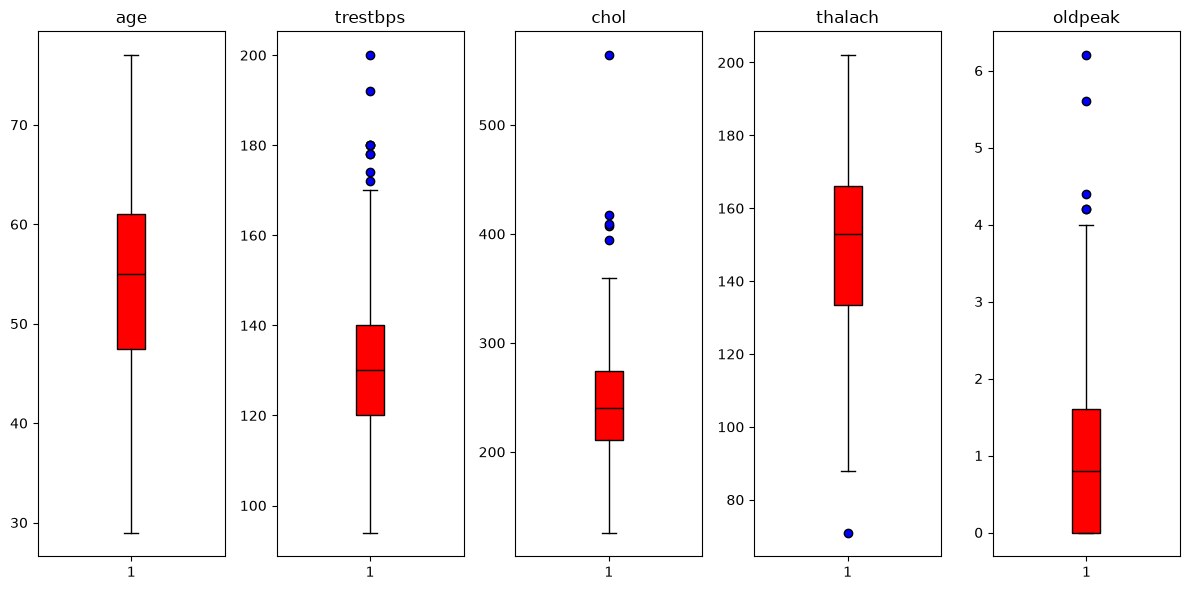

In [13]:
col = numerical
fig , ax = plt.subplots(figsize=(12,6),ncols=len(col))
for i ,column in enumerate(col):
    ax[i].boxplot(df[column],patch_artist=True,boxprops={"facecolor":"red"},medianprops={"color":"black"},flierprops={"markerfacecolor":"blue"})
    ax[i].set_title(column)
plt.tight_layout()

In [14]:
dict_missing = {}
for col in df[numerical]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3-q1
    dict_missing[col] = df[(df[col]> q3 + (iqr * 1.5)) | (df[col] < q1 - (iqr * 1.5))]
for key,value in dict_missing.items():
    print(f"{key}->{len(value)}")


age->0
trestbps->9
chol->5
thalach->1
oldpeak->5


## سوال 13

جدولی ایجاد کنید:

| Feature | Number of Outliers |

---

In [15]:
df_copy = df.copy()
mask = pd.Series(None)
for col in df[numerical]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3-q1
    mask = mask | (df[col]> q3 + (iqr * 1.5)) | (df[col] < q1 - (iqr * 1.5))
    df_copy[col] = df_copy[col].astype(str)
    df_copy.loc[(df[col]> q3 + (iqr * 1.5)) | (df[col] < q1 - (iqr * 1.5)),col] = "*" + df_copy.loc[(df[col]> q3 + (iqr * 1.5)) | (df[col] < q1 - (iqr * 1.5)),col] + "*"
df_copy[mask]


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
8,52,1,2,*172*,199,1,1,162,0,0.5,2,0,3,1
28,65,0,2,140,*417*,1,0,157,0,0.8,2,1,2,1
85,67,0,2,115,*564*,0,0,160,0,1.6,1,0,3,1
96,62,0,0,140,*394*,0,0,157,0,1.2,1,0,2,1
101,59,1,3,*178*,270,0,0,145,0,*4.2*,0,0,3,1
110,64,0,0,*180*,325,0,1,154,1,0.0,2,0,2,1
203,68,1,2,*180*,274,1,0,150,1,1.6,1,0,3,0
204,62,0,0,160,164,0,0,145,0,*6.2*,0,3,3,0
220,63,0,0,150,*407*,0,0,154,0,4.0,1,3,3,0
221,55,1,0,140,217,0,1,111,1,*5.6*,0,0,3,0


## سوال 14

برای Outlier ها سه استراتژی مختلف پیشنهاد دهید.

۱.حذف داده پرت

۲.لگاریتم یا جذر گرفتن از اون ستون

۳.جایگزینی با سقف داده ها یعنی q3 + iqr *1.5

4.جایگزینی با میانگین یا میانه انگار داده گمشده است


---

## سوال 15

یک استراتژی را انتخاب و پیاده‌سازی کنید.

---

In [16]:
df = df[~mask]

# بخش سوم

# Data Construction

---

در این بخش باید ویژگی‌های جدید ایجاد شوند.

---

## سوال 16

سن را به سه گروه تقسیم کنید:

* Young
* Middle Age
* Senior

ستون جدید:

```python
age_group
```

---

In [17]:
age_categorical = []
for index in df["age"]:
    if index < 18:
        index = "young"
        age_categorical.append(index)
    elif 40 > index:
        index = "middle age"
        age_categorical.append(index)
    else:
        index = "senior"
        age_categorical.append(index)
df.insert(1,"age_group",age_categorical)
df

,age,age_group,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,senior,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,middle age,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,senior,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,senior,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,senior,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,senior,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,senior,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,senior,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,senior,1,0,130,131,0,1,115,1,1.2,1,1,3,0


## سوال 17

برای chol سطح ریسک ایجاد کنید:

* Low
* Normal
* High

---

In [18]:
chol_categorical = []
for index in df["chol"]:
    if index < 120:
        index = "Low"
        chol_categorical.append(index)
    elif 200 > index:
        index = "Normal"
        chol_categorical.append(index)
    else:
        index = "High"
        chol_categorical.append(index)
df.insert(6,"chol risk",chol_categorical)
df

,age,age_group,sex,cp,trestbps,chol,chol risk,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,senior,1,3,145,233,High,1,0,150,0,2.3,0,0,1,1
1,37,middle age,1,2,130,250,High,0,1,187,0,3.5,0,0,2,1
2,41,senior,0,1,130,204,High,0,0,172,0,1.4,2,0,2,1
3,56,senior,1,1,120,236,High,0,1,178,0,0.8,2,0,2,1
4,57,senior,0,0,120,354,High,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,senior,0,0,140,241,High,0,1,123,1,0.2,1,0,3,0
299,45,senior,1,3,110,264,High,0,1,132,0,1.2,1,0,3,0
300,68,senior,1,0,144,193,Normal,1,1,141,0,3.4,1,2,3,0
301,57,senior,1,0,130,131,Normal,0,1,115,1,1.2,1,1,3,0


## سوال 18

برای trestbps سطح فشار خون تعریف کنید.

---

In [19]:
trestbps_categorical = []
for index in df["trestbps"]:
    if index < 120:
        index = "Normal"
        trestbps_categorical.append(index)
    elif 200 > index:
        index = "Elavated"
        trestbps_categorical.append(index)
    else:
        index = "Hypertention"
        chol_categorical.append(index)
df.insert(5,"trestbps risk",trestbps_categorical)
df

,age,age_group,sex,cp,trestbps,trestbps risk,chol,chol risk,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,senior,1,3,145,Elavated,233,High,1,0,150,0,2.3,0,0,1,1
1,37,middle age,1,2,130,Elavated,250,High,0,1,187,0,3.5,0,0,2,1
2,41,senior,0,1,130,Elavated,204,High,0,0,172,0,1.4,2,0,2,1
3,56,senior,1,1,120,Elavated,236,High,0,1,178,0,0.8,2,0,2,1
4,57,senior,0,0,120,Elavated,354,High,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,senior,0,0,140,Elavated,241,High,0,1,123,1,0.2,1,0,3,0
299,45,senior,1,3,110,Normal,264,High,0,1,132,0,1.2,1,0,3,0
300,68,senior,1,0,144,Elavated,193,Normal,1,1,141,0,3.4,1,2,3,0
301,57,senior,1,0,130,Elavated,131,Normal,0,1,115,1,1.2,1,1,3,0


## سوال 19

حداقل دو Feature جدید طراحی کنید.

دلایل کسب‌وکاری آن را توضیح دهید.

---

## سوال 20

جدول زیر را تکمیل کنید:

| New Feature | Business Reason |

---

# بخش چهارم

# Data Integration

---

فرض کنید داده جدیدی از آزمایشگاه دریافت شده است.

فایل فرضی:

```python
lab_results.csv
```

---

In [20]:
df_lab = pd.read_csv("lab_results.csv")


## سوال 21

یک DataFrame آزمایشی بسازید.

---

In [21]:
df_lab = df_lab.drop(columns=["Pregnancies","BloodPressure","Age","Outcome","DiabetesPedigreeFunction"])
df_lab_sample = df_lab.sample(n=303,random_state= 42)

## سوال 22

یک کلید مشترک تعریف کنید.

---

In [27]:
df_lab_sample = df_lab_sample.reset_index(drop=True)
df_lab_sample["index"] = df_lab_sample.index
df["index"] = df.index
df_lab_sample

,Glucose,SkinThickness,Insulin,BMI,index
0,98,33,190,34.0,0
1,112,32,0,35.7,1
2,108,0,0,30.8,2
3,107,0,0,24.6,3
4,136,0,0,29.9,4
...,...,...,...,...,...
298,100,0,0,30.0,298
299,126,38,75,25.9,299
300,111,39,0,30.1,300
301,144,26,285,32.0,301


## سوال 23

Merge را انجام دهید.

---

## سوال 24

انواع Merge زیر را مقایسه کنید:

* inner
* left
* right
* outer

---

In [ ]:
df_merge_left = pd.merge(df,df_lab_sample,on="index",how="left")
df_merge_right = pd.merge(df,df_lab_sample,on="index",how="right")
df_merge_inner = pd.merge(df,df_lab_sample,on="index",how="inner")
df_merge_outer= pd.merge(df,df_lab_sample,on="index",how="outer")


,age,age_group,sex,cp,trestbps,trestbps risk,chol,chol risk,fbs,restecg,...,oldpeak,slope,ca,thal,target,index,Glucose,SkinThickness,Insulin,BMI
0,63,senior,1,3,145,Elavated,233,High,1,0,...,2.3,0,0,1,1,0,98,33,190,34.0
1,37,middle age,1,2,130,Elavated,250,High,0,1,...,3.5,0,0,2,1,1,112,32,0,35.7
2,41,senior,0,1,130,Elavated,204,High,0,0,...,1.4,2,0,2,1,2,108,0,0,30.8
3,56,senior,1,1,120,Elavated,236,High,0,1,...,0.8,2,0,2,1,3,107,0,0,24.6
4,57,senior,0,0,120,Elavated,354,High,0,1,...,0.6,2,0,2,1,4,136,0,0,29.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279,57,senior,0,0,140,Elavated,241,High,0,1,...,0.2,1,0,3,0,298,100,0,0,30.0
280,45,senior,1,3,110,Normal,264,High,0,1,...,1.2,1,0,3,0,299,126,38,75,25.9
281,68,senior,1,0,144,Elavated,193,Normal,1,1,...,3.4,1,2,3,0,300,111,39,0,30.1
282,57,senior,1,0,130,Elavated,131,Normal,0,1,...,1.2,1,1,3,0,301,144,26,285,32.0


## سوال 25

مشخص کنید برای این پروژه کدام نوع Merge مناسب‌تر است.

---

In [34]:
df = df_merge_inner

# بخش پنجم

# Data Formatting

---

## سوال 26

نوع داده تمامی ستون‌ها را بررسی کنید.

---

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284 entries, 0 to 283
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            284 non-null    int64  
 1   age_group      284 non-null    str    
 2   sex            284 non-null    int64  
 3   cp             284 non-null    int64  
 4   trestbps       284 non-null    int64  
 5   trestbps risk  284 non-null    str    
 6   chol           284 non-null    int64  
 7   chol risk      284 non-null    str    
 8   fbs            284 non-null    int64  
 9   restecg        284 non-null    int64  
 10  thalach        284 non-null    int64  
 11  exang          284 non-null    int64  
 12  oldpeak        284 non-null    float64
 13  slope          284 non-null    int64  
 14  ca             284 non-null    int64  
 15  thal           284 non-null    int64  
 16  target         284 non-null    int64  
 17  index          284 non-null    int64  
 18  Glucose        284 no

## سوال 27

ستون‌هایی که باید Category باشند را شناسایی کنید.

---

In [46]:
numerical = []
categorical = []
boolian = []
for index , col in enumerate(df.columns):
    if df[col].dtype is not "str":
        number_unique = df[col].nunique()
        if number_unique == 2:
            boolian.append(col)
        elif 6 > number_unique > 2:
            categorical.append(col)
        else:
            numerical.append(col)

<>:5: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
<>:5: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
/tmp/ipykernel_8830/3240490796.py:5: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
  if df[col].dtype is not "str":


## سوال 28

Datatype مناسب را اعمال کنید.

---

## سوال 29

حجم حافظه قبل و بعد از تغییر datatype را مقایسه کنید.

---

## سوال 30

ستون‌های متنی را استانداردسازی کنید.

مثال:

```python
Male
male
MALE
```

---

# بخش ششم

# Data Reduction

---

## سوال 31

ویژگی‌های دارای واریانس بسیار کم را شناسایی کنید.

---

In [47]:
df[numerical].var().sort_values()

oldpeak              1.052966
BMI                 71.489128
age                 83.936346
trestbps           236.179503
SkinThickness      286.583126
thalach            514.959339
Glucose            971.742435
chol              2002.905639
index             7608.575524
Insulin          12826.079431
dtype: float64

## سوال 32

ویژگی‌های بسیار همبسته را شناسایی کنید.

---

In [48]:
lst = df.columns(exclude=["object","str"])

TypeError: 'Index' object is not callable

## سوال 33

Heatmap جدید رسم کنید.

---

## سوال 34

اگر دو ویژگی همبستگی بالای 0.85 دارند:

کدام را حذف می‌کنید؟

چرا؟

---

## سوال 35

یک نسخه کاهش‌یافته از دیتاست ایجاد کنید.

نام:

```python
reduced_df
```

---

# بخش هفتم

# Data Transformation

---

# Normalization & Scaling

---

## سوال 36

بررسی کنید آیا ویژگی‌های عددی مقیاس‌های متفاوت دارند یا خیر.

---

## سوال 37

برای تمام ویژگی‌های عددی:

Min-Max Scaling را با NumPy پیاده‌سازی کنید.

فرمول:

```python
(x-min)/(max-min)
```

---

## سوال 38

برای تمام ویژگی‌های عددی:

Standardization را با NumPy پیاده‌سازی کنید.

---

## سوال 39

قبل و بعد از Scaling:

Histogram رسم کنید.

---

## سوال 40

مقایسه کنید:

* MinMax
* Standardization

برای این پروژه کدام مناسب‌تر است؟

---

# بخش هشتم

# Dataset Validation

---

## سوال 41

شکل نهایی دیتاست را گزارش کنید.

---

## سوال 42

آیا Null باقی مانده است؟

---

## سوال 43

آیا Duplicate باقی مانده است؟

---

## سوال 44

آیا Outlier ها مدیریت شده‌اند؟

---

## سوال 45

آیا تمامی ویژگی‌ها فرمت مناسبی دارند؟

---

## سوال 46

آیا داده برای KNN مناسب است؟

توضیح دهید.

---

## سوال 47

آیا داده برای Logistic Regression مناسب است؟

توضیح دهید.

---

## سوال 48

آیا داده برای Decision Tree مناسب است؟

توضیح دهید.

---

## سوال 49

دیتاست نهایی را ذخیره کنید:

```python
heart_prepared.csv
```

---

## سوال 50

یک گزارش مدیریتی تهیه کنید.

به سوالات زیر پاسخ دهید:

1. چه تغییراتی روی داده انجام شد؟
2. چه ویژگی‌هایی حذف شدند؟
3. چه ویژگی‌هایی ساخته شدند؟
4. چه مشکلاتی برطرف شد؟
5. آیا داده برای Modeling آماده است؟

---

# تحویل پروژه

فایل‌های زیر باید ارسال شوند:

```python
task002_data_preparation.ipynb
heart_prepared.csv
```

---

# هدف آموزشی این تسک

پس از پایان این تمرین دانشجو باید بتواند:

✅ Data Selection انجام دهد

✅ Data Cleaning انجام دهد

✅ Feature Construction انجام دهد

✅ Data Integration انجام دهد

✅ Data Formatting انجام دهد

✅ Data Reduction انجام دهد

✅ Scaling و Normalization انجام دهد

✅ یک دیتاست خام را به یک دیتاست آماده مدل‌سازی تبدیل کند

این دقیقاً خروجی مورد انتظار مرحله Data Preparation در فرآیند CRISP-DM است.